Objective

Study the effect of leak size on

• Pressure
• Flow
• Velocity
• Headloss

Theory

Leak behaves like an additional demand.

Leak ↑

↓

Pressure ↓

Flow redistribution ↑

Velocity changes

Headloss ↑

In [4]:
import wntr
import copy
import pandas as pd
import matplotlib.pyplot as plt

wn = wntr.network.WaterNetworkModel(
    "production_benchmark.inp"
)

In [5]:
leak_sizes = [
    0.00,
    0.02,
    0.05,
    0.10,
    0.15,
    0.20,
    0.30
]
inch = 0.02548

In [6]:
benchmark = []

for leak in leak_sizes:

    wn_test = copy.deepcopy(wn)

    # Remove original P2
    wn_test.remove_link("P2")

    # Add leak junction
    wn_test.add_junction(
        "Leak_Junction",
        base_demand=leak,
        elevation=12
    )

    wn_test.get_node(
        "Leak_Junction"
    ).coordinates = (6,5)

    # Split P2 into two pipes

    wn_test.add_pipe(
        "P2A",
        "J1",
        "Leak_Junction",
        length=600,
        diameter=25*inch,
        roughness=100
    )

    wn_test.add_pipe(
        "P2B",
        "Leak_Junction",
        "J2",
        length=600,
        diameter=25*inch,
        roughness=100
    )

    sim = wntr.sim.EpanetSimulator(
        wn_test
    )

    result = sim.run_sim()

    pressure = result.node["pressure"].iloc[-1]
    flow = result.link["flowrate"].iloc[-1]
    velocity = result.link["velocity"].iloc[-1]
    headloss = result.link["headloss"].iloc[-1]

    row = {

        "Leak_Size": leak

    }

    for node in pressure.index:

        row[f"Pressure_{node}"] = pressure[node]

    for pipe in flow.index:

        row[f"Flow_{pipe}"] = flow[pipe]

    for pipe in velocity.index:

        row[f"Velocity_{pipe}"] = velocity[pipe]

    for pipe in headloss.index:

        row[f"Headloss_{pipe}"] = headloss[pipe]

    benchmark.append(row)

benchmark_df = pd.DataFrame(benchmark)

benchmark_df

,Leak_Size,Pressure_J1,Pressure_J2,Pressure_J3,Pressure_J4,Pressure_Customer_A,Pressure_Customer_B,Pressure_Customer_C,Pressure_Leak_Junction,Pressure_Source,...,Velocity_P2A,Velocity_P2B,Headloss_P1,Headloss_P3,Headloss_P4,Headloss_P5,Headloss_P6,Headloss_P7,Headloss_P2A,Headloss_P2B
0,0.00,102.520699,96.349419,93.645836,74.171478,83.514473,81.956085,55.639431,98.435059,-0.000004,...,1.255138,1.255138,0.007479,0.004844,0.016474,0.00967,0.007322,0.016474,0.003476,0.003476
1,0.02,102.052429,95.683914,93.177567,73.703209,82.848976,81.290588,55.171158,97.769554,-0.000004,...,1.317895,1.255138,0.007948,0.004844,0.016474,0.00967,0.007322,0.016474,0.003805,0.003476
2,0.05,101.325569,94.645920,92.450722,72.976364,81.810974,80.252579,54.444309,96.731560,-0.000004,...,1.412030,1.255138,0.008674,0.004844,0.016474,0.00967,0.007322,0.016474,0.004323,0.003476
3,0.10,100.049461,92.810890,91.174599,71.700249,79.975937,78.417542,53.168194,94.896530,-0.000004,...,1.568922,1.255138,0.009951,0.004844,0.016474,0.00967,0.007322,0.016474,0.005255,0.003476
4,0.15,98.693237,90.845970,89.818382,70.344017,78.011017,76.452637,51.811966,92.931610,-0.000004,...,1.725815,1.255138,0.011307,0.004844,0.016474,0.00967,0.007322,0.016474,0.006269,0.003476
5,0.20,97.257713,88.752701,88.382851,68.908493,75.917755,74.359375,50.376438,90.838341,-0.000004,...,1.882707,1.255138,0.012742,0.004844,0.016474,0.00967,0.007322,0.016474,0.007366,0.003476
6,0.30,94.151718,84.186516,85.276863,65.802513,71.351562,69.793190,47.270454,86.272156,-0.000004,...,2.196491,1.255138,0.015848,0.004844,0.016474,0.00967,0.007322,0.016474,0.009799,0.003476


In [7]:
benchmark_df.to_csv(
    "Leak_Size_Benchmark.csv",
    index=False
)

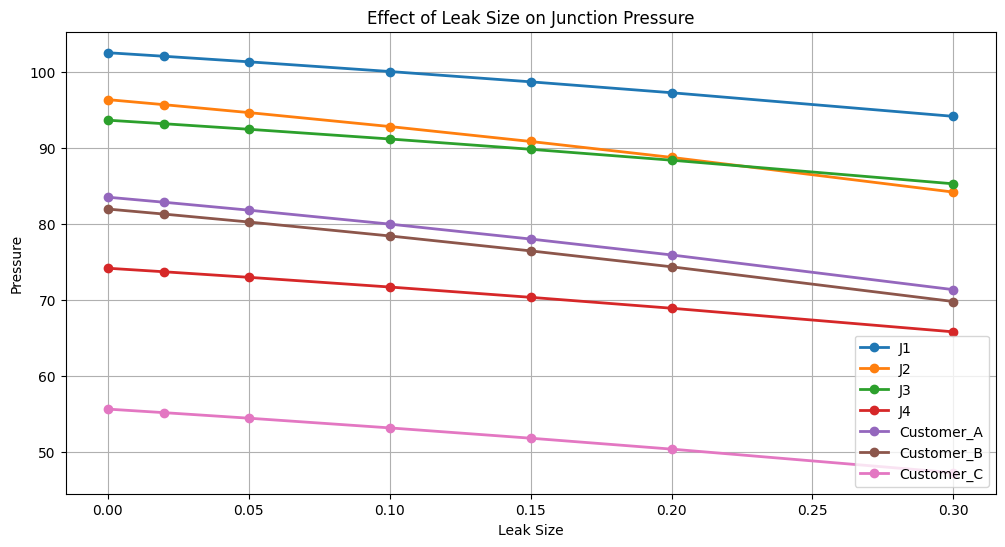

In [8]:
plt.figure(figsize=(12,6))

pressure_nodes = [

    "Pressure_J1",
    "Pressure_J2",
    "Pressure_J3",
    "Pressure_J4",
    "Pressure_Customer_A",
    "Pressure_Customer_B",
    "Pressure_Customer_C"

]

for node in pressure_nodes:

    plt.plot(

        benchmark_df["Leak_Size"],

        benchmark_df[node],

        marker="o",

        linewidth=2,

        label=node.replace("Pressure_","")

    )

plt.grid(True)

plt.xlabel("Leak Size")

plt.ylabel("Pressure")

plt.title("Effect of Leak Size on Junction Pressure")

plt.legend()

plt.show()

# Pressure decreases as leak size increases
Leak acts as an extra demand:

Qsource = Q customers + Qleak

More water leaves the system.

More flow through upstream pipes means more friction losses.

More friction loss means

Pressure↓

Especially after the leak.
	​


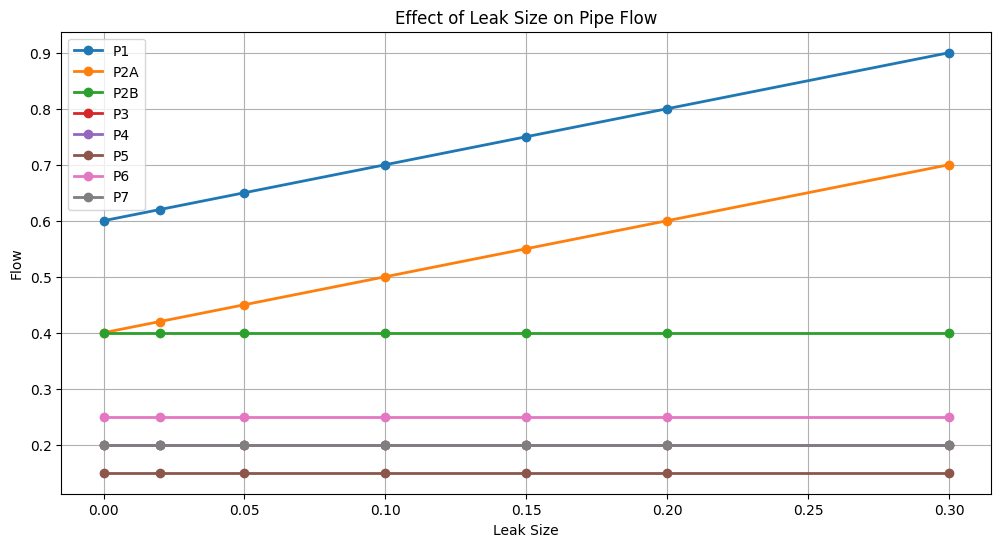

In [9]:
plt.figure(figsize=(12,6))

pipes = [

    "Flow_P1",
    "Flow_P2A",
    "Flow_P2B",
    "Flow_P3",
    "Flow_P4",
    "Flow_P5",
    "Flow_P6",
    "Flow_P7"

]

for pipe in pipes:

    plt.plot(

        benchmark_df["Leak_Size"],

        benchmark_df[pipe],

        marker="o",

        linewidth=2,

        label=pipe.replace("Flow_","")

    )

plt.grid(True)

plt.xlabel("Leak Size")

plt.ylabel("Flow")

plt.title("Effect of Leak Size on Pipe Flow")

plt.legend()

plt.show()

# Flow in P1 and P2A increases

Suppose

Customers need

0.60 L/s

Now leak is

0.20 L/s

Source must now supply

0.80 L/s

Therefore

Flow in P1 ↑

Flow in P2A ↑

because they are upstream of the leak.

After the leak

(P2B)

flow may decrease because some water already escaped

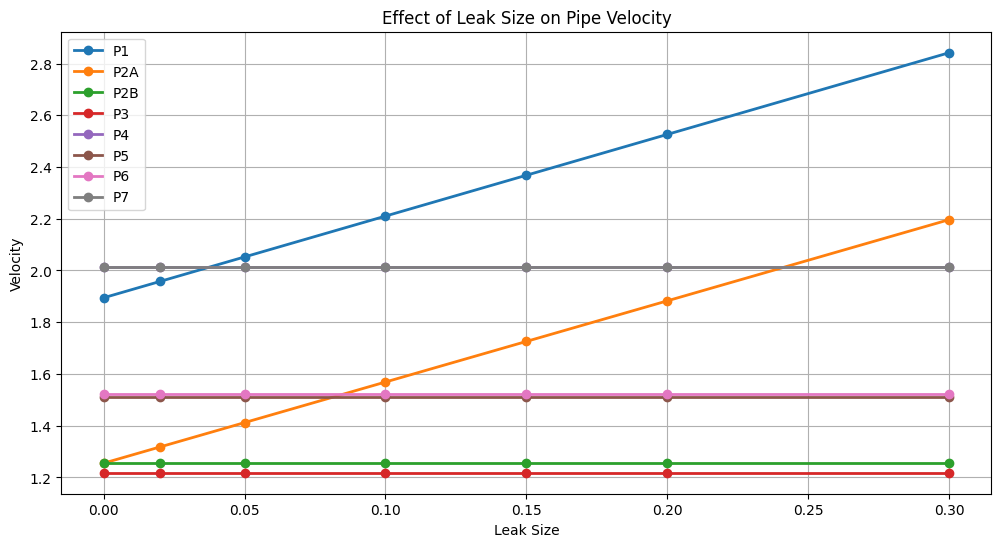

In [10]:
plt.figure(figsize=(12,6))

pipes = [

    "Velocity_P1",
    "Velocity_P2A",
    "Velocity_P2B",
    "Velocity_P3",
    "Velocity_P4",
    "Velocity_P5",
    "Velocity_P6",
    "Velocity_P7"

]

for pipe in pipes:

    plt.plot(

        benchmark_df["Leak_Size"],

        benchmark_df[pipe],

        marker="o",

        linewidth=2,

        label=pipe.replace("Velocity_","")

    )

plt.grid(True)

plt.xlabel("Leak Size")

plt.ylabel("Velocity")

plt.title("Effect of Leak Size on Pipe Velocity")

plt.legend()

plt.show()

# Velocity of P1 and P2A increases

Velocity

V=Q/A
	​
Diameter is constant.

Area is constant.

Leak causes

Flow ↑

Therefore

Velocity ↑

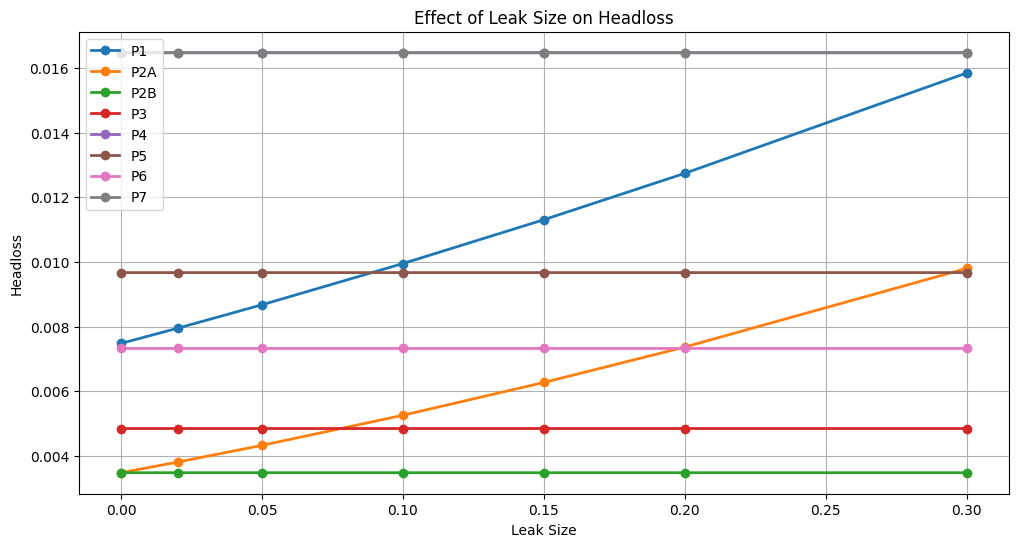

In [11]:
plt.figure(figsize=(12,6))

pipes = [

    "Headloss_P1",
    "Headloss_P2A",
    "Headloss_P2B",
    "Headloss_P3",
    "Headloss_P4",
    "Headloss_P5",
    "Headloss_P6",
    "Headloss_P7"

]

for pipe in pipes:

    plt.plot(

        benchmark_df["Leak_Size"],

        benchmark_df[pipe],

        marker="o",

        linewidth=2,

        label=pipe.replace("Headloss_","")

    )

plt.grid(True)

plt.xlabel("Leak Size")

plt.ylabel("Headloss")

plt.title("Effect of Leak Size on Headloss")

plt.legend()

plt.show()

# Headloss of P1 and P2A increases
 According to Hazen Williams Formula

 Diameter constant

Length constant

Roughness constant

Only Q increases  , Since

hf ∝ Q1.852

Headloss increases rapidly.

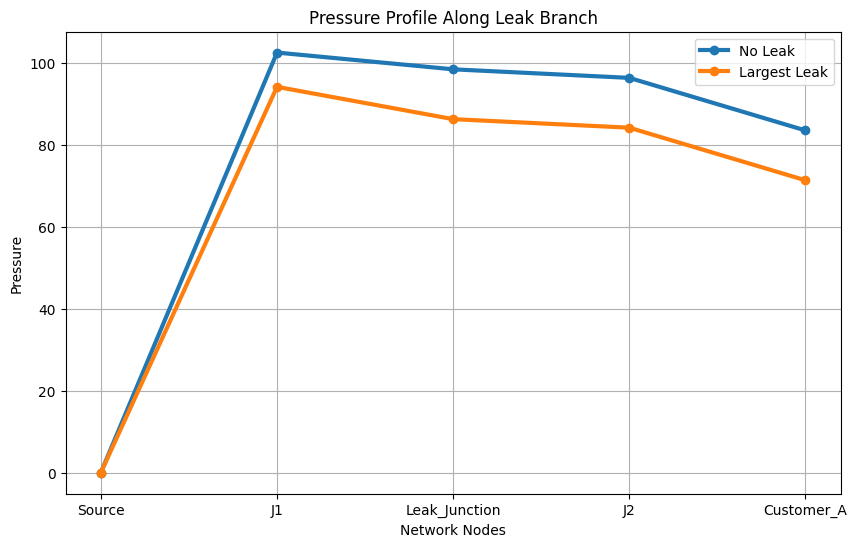

In [12]:
baseline = benchmark_df[
    benchmark_df["Leak_Size"] == 0.00
].iloc[0]

largest = benchmark_df[
    benchmark_df["Leak_Size"] == 0.30
].iloc[0]

nodes = [

    "Source",
    "J1",
    "Leak_Junction",
    "J2",
    "Customer_A"

]

baseline_pressure = [

    baseline["Pressure_Source"],
    baseline["Pressure_J1"],
    baseline["Pressure_Leak_Junction"],
    baseline["Pressure_J2"],
    baseline["Pressure_Customer_A"]

]

largest_pressure = [

    largest["Pressure_Source"],
    largest["Pressure_J1"],
    largest["Pressure_Leak_Junction"],
    largest["Pressure_J2"],
    largest["Pressure_Customer_A"]

]

plt.figure(figsize=(10,6))

plt.plot(

    nodes,

    baseline_pressure,

    marker="o",

    linewidth=3,

    label="No Leak"

)

plt.plot(

    nodes,

    largest_pressure,

    marker="o",

    linewidth=3,

    label="Largest Leak"

)

plt.grid(True)

plt.xlabel("Network Nodes")

plt.ylabel("Pressure")

plt.title("Pressure Profile Along Leak Branch")

plt.legend()

plt.show()

In [13]:
benchmark_df[[
    "Leak_Size",
    "Flow_P1",
    "Flow_P2A",
    "Flow_P2B",
    "Flow_P5",
    "Flow_P6"
]]

,Leak_Size,Flow_P1,Flow_P2A,Flow_P2B,Flow_P5,Flow_P6
0,0.00,0.60,0.40,0.4,0.15,0.25
1,0.02,0.62,0.42,0.4,0.15,0.25
2,0.05,0.65,0.45,0.4,0.15,0.25
3,0.10,0.70,0.50,0.4,0.15,0.25
4,0.15,0.75,0.55,0.4,0.15,0.25
5,0.20,0.80,0.60,0.4,0.15,0.25
6,0.30,0.90,0.70,0.4,0.15,0.25


Observations

• Increasing leak size reduces downstream pressure.

• Source flow increases because additional water leaves through the leak.

• Velocity changes mainly near the leak location.

• Headloss increases around the leak branch.

• The hydraulic influence is strongest close to the leak and weakens farther away.

Conclusion

Leak size produces measurable hydraulic signatures that can later be used for leak detection and localization.